In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [3]:
df=pd.read_csv("loan_approval_data.csv")

In [99]:
df.head()
df.info()
df.isnull().sum()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 32 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_ID                     1000 non-null   float64
 1   Applicant_Income                 1000 non-null   float64
 2   Coapplicant_Income               1000 non-null   float64
 3   Age                              1000 non-null   float64
 4   Dependents                       1000 non-null   float64
 5   Credit_Score                     1000 non-null   float64
 6   Existing_Loans                   1000 non-null   float64
 7   DTI_Ratio                        1000 non-null   float64
 8   Savings                          1000 non-null   float64
 9   Collateral_Value                 1000 non-null   float64
 10  Loan_Amount                      1000 non-null   float64
 11  Loan_Term                        1000 non-null   float64
 12  Education_Level                 

In [5]:
categorical_cols=df.select_dtypes(include=["str"]).columns
numerical_cols=df.select_dtypes(include=["float64"]).columns

In [6]:
categorical_cols.size+numerical_cols.size

20

In [7]:
from sklearn.impute import SimpleImputer
num_imp=SimpleImputer(strategy="mean")
df[numerical_cols]=num_imp.fit_transform(df[numerical_cols])

In [8]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [9]:
cat_imp=SimpleImputer(strategy="most_frequent")
df[categorical_cols]=cat_imp.fit_transform(df[categorical_cols])

In [10]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


Text(0.5, 1.0, 'Is loan approved or Not')

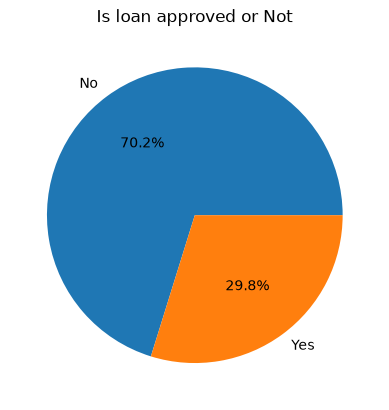

In [11]:
classes_count=df["Loan_Approved"].value_counts()
plt.pie(classes_count,labels=["No","Yes",],autopct="%1.1f%%")
plt.title("Is loan approved or Not")

[Text(0, 0, '722'), Text(0, 0, '278')]

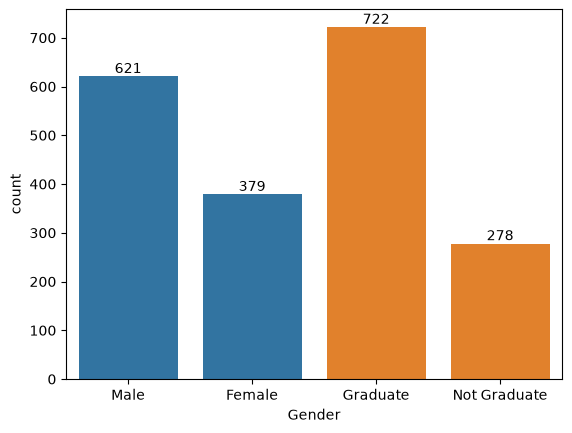

In [12]:
gender_cnt=df["Gender"].value_counts()
ax=sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])

ed_cnt=df["Education_Level"].value_counts()
ax=sns.barplot(ed_cnt)
ax.bar_label(ax.containers[1])



<Axes: xlabel='Applicant_Income', ylabel='Count'>

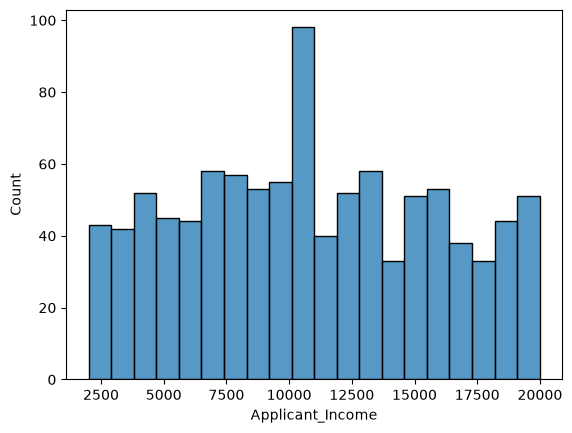

In [13]:
sns.histplot(data=df,
             x="Applicant_Income",
             bins=20
            )

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

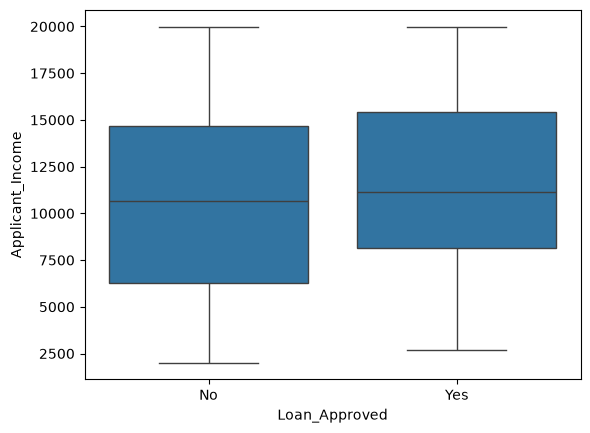

In [14]:
sns.boxplot(data=df,
           x="Loan_Approved",
           y="Applicant_Income"
          )

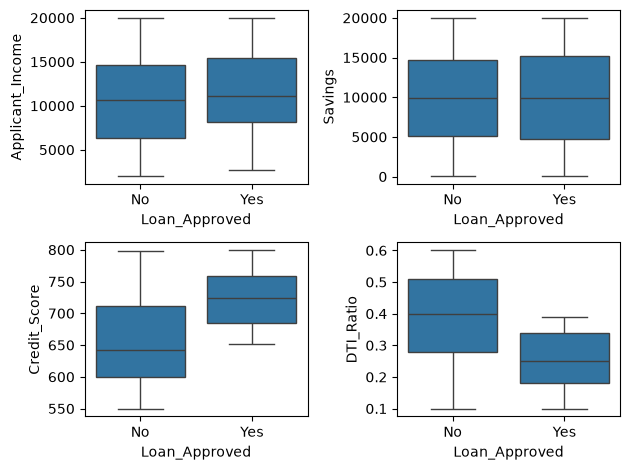

In [15]:
fig,ax=plt.subplots(2,2)
sns.boxplot(ax=ax[0,0],data=df,x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=ax[0,1],data=df,x="Loan_Approved",y="Savings")
sns.boxplot(ax=ax[1,0],data=df,x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=ax[1,1],data=df,x="Loan_Approved",y="DTI_Ratio")
plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

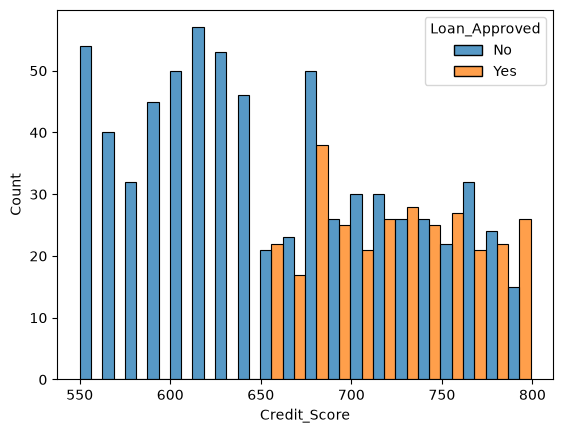

In [16]:
sns.histplot(data=df,x="Credit_Score", hue="Loan_Approved",
             bins=20,
             multiple="dodge"
            )

In [17]:
print(df.columns)

df.head()

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income',
       'Employment_Status', 'Age', 'Marital_Status', 'Dependents',
       'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term', 'Loan_Purpose',
       'Property_Area', 'Education_Level', 'Gender', 'Employer_Category',
       'Loan_Approved'],
      dtype='str')


,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [98]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
le=LabelEncoder()
df["Education_Level"]=le.fit_transform(df["Education_Level"])
df["Loan_Approved"]=le.fit_transform(df["Loan_Approved"])
df.head()
le_education = LabelEncoder()
df["Education_Level"] = le_education.fit_transform(df["Education_Level"])

print(le_education.classes_)
print(df["Loan_Approved"].value_counts())
print(df["Education_Level"].unique())


[0 1]
Loan_Approved
0    702
1    298
Name: count, dtype: int64
[1 0]


In [24]:
cols=["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]
one=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
encoded=one.fit_transform(df[cols])
encoded_df=pd.DataFrame(encoded,columns=one.get_feature_names_out(cols),index=df.index)
df=pd.concat([df.drop(columns=cols),encoded_df],axis=1)

In [25]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,1.0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2.0,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,3.0,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,4.0,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,5.0,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [34]:
num_cols=df.select_dtypes(include="number")
corr_matrix=num_cols.corr()
num_cols.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Applicant_ID                      -0.011167
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed    

In [35]:
corr_matrix

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
Applicant_ID,1.000000,0.020970,0.041140,0.014579,0.012495,-0.028170,0.024995,0.000174,0.022692,0.031759,...,0.005426,-0.039878,0.019178,0.012969,-0.030187,0.036067,0.005906,-0.074056,0.022803,0.038417
Applicant_Income,0.020970,1.000000,0.007545,-0.023988,-0.026658,-0.009818,-0.010457,-0.009107,-0.028358,0.018789,...,0.032794,0.074209,-0.031234,0.004845,-0.036260,-0.020871,-0.025011,0.102589,-0.044639,-0.011995
Coapplicant_Income,0.041140,0.007545,1.000000,0.014306,-0.026733,0.058423,0.012418,0.058078,-0.015047,0.009457,...,0.028000,0.016022,0.059549,-0.010058,0.030045,-0.010148,-0.001146,0.037640,0.004312,-0.047929
Age,0.014579,-0.023988,0.014306,1.000000,-0.018767,-0.004212,0.023330,0.007903,-0.000986,0.037382,...,-0.006283,0.029865,0.037293,0.003100,-0.025661,0.048402,-0.066041,0.021232,-0.012960,0.072462
Dependents,0.012495,-0.026658,-0.026733,-0.018767,1.000000,-0.007687,-0.026338,0.011498,-0.004981,0.023004,...,-0.044642,0.027343,-0.005785,-0.032278,0.024082,0.013706,-0.009250,-0.018757,0.030197,-0.054147
Credit_Score,-0.028170,-0.009818,0.058423,-0.004212,-0.007687,1.000000,-0.007130,0.002338,-0.065353,0.007865,...,0.026013,-0.008658,0.015324,-0.006946,0.004445,-0.039739,-0.007076,0.066736,-0.000049,-0.046087
Existing_Loans,0.024995,-0.010457,0.012418,0.023330,-0.026338,-0.007130,1.000000,0.047008,0.034435,-0.049916,...,-0.010035,0.001777,0.023212,-0.053971,0.035629,-0.038762,-0.009642,0.030520,-0.019306,0.045391
DTI_Ratio,0.000174,-0.009107,0.058078,0.007903,0.011498,0.002338,0.047008,1.000000,0.004663,-0.009622,...,0.040432,-0.014125,-0.036648,0.044898,-0.006156,0.009624,-0.007214,0.002090,-0.003506,0.026018
Savings,0.022692,-0.028358,-0.015047,-0.000986,-0.004981,-0.065353,0.034435,0.004663,1.000000,0.015481,...,0.032558,-0.012217,-0.028948,0.005438,0.016833,-0.006667,-0.011683,0.004381,-0.030208,0.027178
Collateral_Value,0.031759,0.018789,0.009457,0.037382,0.023004,0.007865,-0.049916,-0.009622,0.015481,1.000000,...,0.040406,-0.050975,-0.007120,0.020061,0.007975,0.000897,0.035760,-0.013464,-0.014480,-0.009655


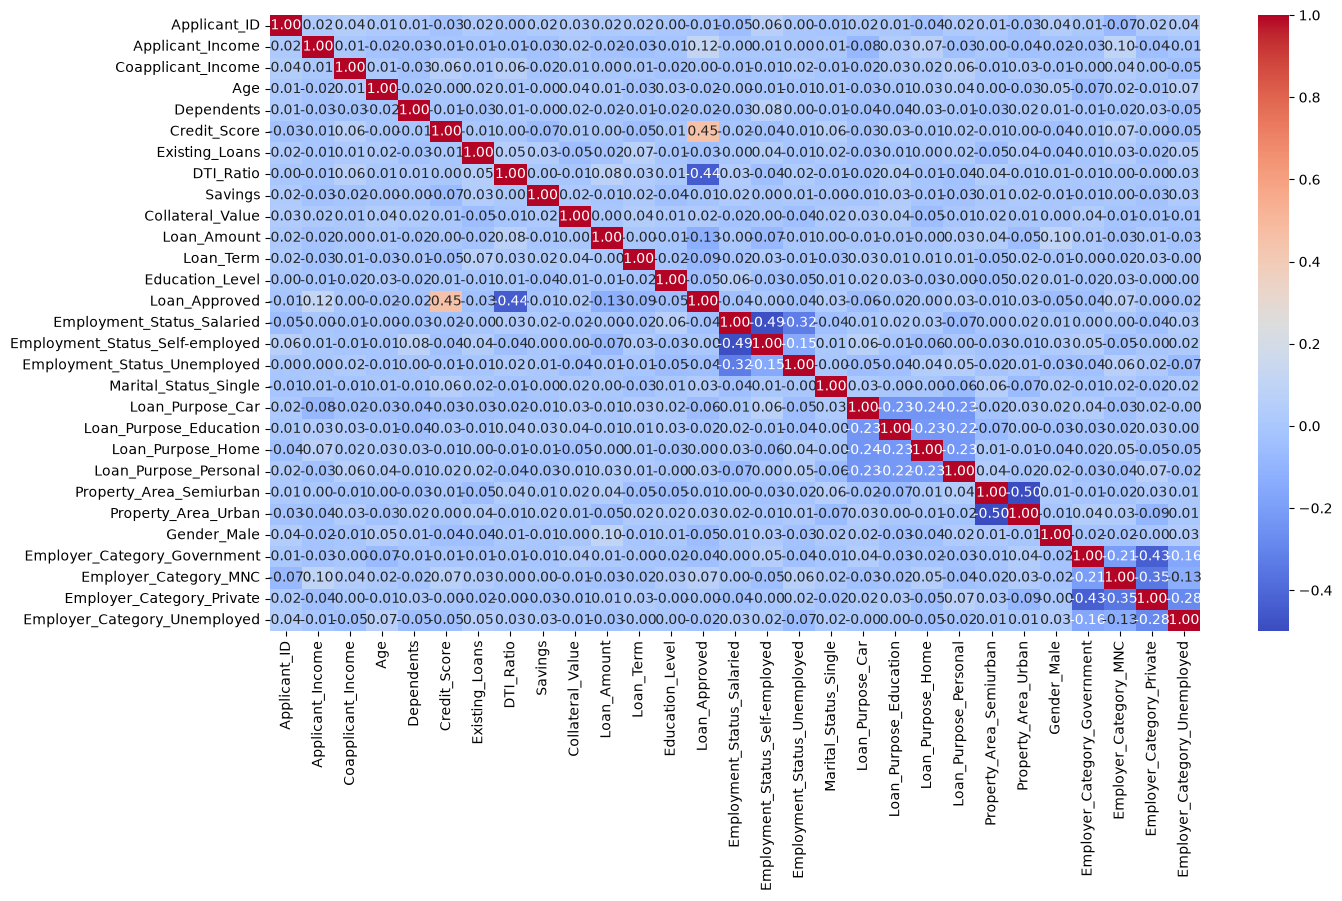

In [36]:
plt.figure(figsize=(15, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.show()

In [40]:
X=df.drop(columns="Loan_Approved")
y=df["Loan_Approved"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=34)


In [102]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score
log_model=LogisticRegression()
log_model.fit(X_scaled,y_train)
y_pred=log_model.predict(X_test_scaled)
log_model

print("Precision",precision_score(y_test,y_pred))
print("accuracy score",accuracy_score(y_test,y_pred))
print("Recall",recall_score(y_test,y_pred))
print("CM",confusion_matrix(y_test,y_pred))

Precision 0.7586206896551724
accuracy score 0.795
Recall 0.6197183098591549
CM [[115  14]
 [ 27  44]]


In [64]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score
knn_model=KNeighborsClassifier(n_neighbors=9)
knn_model.fit(X_scaled,y_train)
y_pred=knn_model.predict(X_test_scaled)
knn_model


print("Precision",precision_score(y_test,y_pred))
print("accuracy score",accuracy_score(y_test,y_pred))
print("Recall",recall_score(y_test,y_pred))
print("CM",confusion_matrix(y_test,y_pred))

Precision 0.6486486486486487
accuracy score 0.7
Recall 0.3380281690140845
CM [[116  13]
 [ 47  24]]


In [66]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score
nav_model=GaussianNB()
nav_model.fit(X_scaled,y_train)
y_pred=nav_model.predict(X_test_scaled)
nav_model

print("Precision",precision_score(y_test,y_pred))
print("accuracy score",accuracy_score(y_test,y_pred))
print("Recall",recall_score(y_test,y_pred))
print("CM",confusion_matrix(y_test,y_pred))

Precision 0.7916666666666666
accuracy score 0.785
Recall 0.5352112676056338
CM [[119  10]
 [ 33  38]]


In [78]:
df["DTI_Ratio_sq"]=df["DTI_Ratio"]**2
df["Credit_Score_sq"]=df["Credit_Score"]**2
df["Applicant_Income_log"]=np.log1p(df["Applicant_Income"])
X=df.drop(columns=["DTI_Ratio","Credit_Score","Loan_Approved"])
y=df["Loan_Approved"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=34)
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [79]:
X_train.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Existing_Loans,Savings,Collateral_Value,Loan_Amount,Loan_Term,...,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,DTI_Ratio_sq,Credit_Score_sq,Applicant_Income_log
634,635.0,5266.000000,8320.0,33.0,3.0,4.000000,13378.0,18105.0,22050.0,12.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.2116,505521.0,8.569216
512,513.0,11588.000000,352.0,41.0,3.0,2.000000,7412.0,13864.0,29783.0,72.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.1681,576081.0,9.357812
144,145.0,3636.000000,3042.0,24.0,2.0,1.000000,5873.0,21876.0,34746.0,36.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0784,534361.0,8.198914
503,504.0,10852.571579,7057.0,55.0,0.0,1.950526,3424.0,7210.0,23402.0,24.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0361,360000.0,9.292249
722,723.0,13613.000000,8906.0,35.0,2.0,2.000000,18913.0,3809.0,17997.0,84.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.1156,518400.0,9.518854


In [80]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score
log_model=LogisticRegression()
log_model.fit(X_scaled,y_train)
y_pred=log_model.predict(X_test_scaled)
log_model

print("Precision",precision_score(y_test,y_pred))
print("accuracy score",accuracy_score(y_test,y_pred))
print("Recall",recall_score(y_test,y_pred))
print("CM",confusion_matrix(y_test,y_pred))

Precision 0.7868852459016393
accuracy score 0.82
Recall 0.676056338028169
CM [[116  13]
 [ 23  48]]


In [83]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_scaled,y_train)
y_pred=knn_model.predict(X_test_scaled)
knn_model


print("Precision",precision_score(y_test,y_pred))
print("accuracy score",accuracy_score(y_test,y_pred))
print("Recall",recall_score(y_test,y_pred))

Precision 0.6590909090909091
accuracy score 0.715
Recall 0.4084507042253521


In [86]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score
nav_model=GaussianNB()
nav_model.fit(X_scaled,y_train)
y_pred=nav_model.predict(X_test_scaled)
from sklearn.metrics import classification_report
print("naive_model",classification_report(y_test,y_pred))

print("Precision",precision_score(y_test,y_pred))
print("accuracy score",accuracy_score(y_test,y_pred))
print("Recall",recall_score(y_test,y_pred))
print("CM",confusion_matrix(y_test,y_pred))

naive_model               precision    recall  f1-score   support

           0       0.78      0.93      0.85       129
           1       0.81      0.54      0.64        71

    accuracy                           0.79       200
   macro avg       0.80      0.73      0.75       200
weighted avg       0.79      0.79      0.78       200

Precision 0.8085106382978723
accuracy score 0.79
Recall 0.5352112676056338
CM [[120   9]
 [ 33  38]]


In [85]:
from sklearn.metrics import classification_report
print("naive_model",classification_report(y_test,y_pred))

naive_model               precision    recall  f1-score   support

           0       0.73      0.88      0.80       129
           1       0.66      0.41      0.50        71

    accuracy                           0.71       200
   macro avg       0.69      0.65      0.65       200
weighted avg       0.71      0.71      0.70       200



In [89]:
import joblib

joblib.dump(nav_model, "loan_model.pkl")

['loan_model.pkl']

In [90]:
import os

print(os.path.exists("loan_model.pkl"))

True


In [91]:
print(X_train.columns.tolist())

['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age', 'Dependents', 'Existing_Loans', 'Savings', 'Collateral_Value', 'Loan_Amount', 'Loan_Term', 'Education_Level', 'Employment_Status_Salaried', 'Employment_Status_Self-employed', 'Employment_Status_Unemployed', 'Marital_Status_Single', 'Loan_Purpose_Car', 'Loan_Purpose_Education', 'Loan_Purpose_Home', 'Loan_Purpose_Personal', 'Property_Area_Semiurban', 'Property_Area_Urban', 'Gender_Male', 'Employer_Category_Government', 'Employer_Category_MNC', 'Employer_Category_Private', 'Employer_Category_Unemployed', 'DTI_Ratio_sq', 'Credit_Score_sq', 'Applicant_Income_log']


In [92]:
print(X.columns.tolist())

['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age', 'Dependents', 'Existing_Loans', 'Savings', 'Collateral_Value', 'Loan_Amount', 'Loan_Term', 'Education_Level', 'Employment_Status_Salaried', 'Employment_Status_Self-employed', 'Employment_Status_Unemployed', 'Marital_Status_Single', 'Loan_Purpose_Car', 'Loan_Purpose_Education', 'Loan_Purpose_Home', 'Loan_Purpose_Personal', 'Property_Area_Semiurban', 'Property_Area_Urban', 'Gender_Male', 'Employer_Category_Government', 'Employer_Category_MNC', 'Employer_Category_Private', 'Employer_Category_Unemployed', 'DTI_Ratio_sq', 'Credit_Score_sq', 'Applicant_Income_log']
